# Language Detection Notebook

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

In [101]:
%pip install datasets
from datasets import load_dataset

ds = load_dataset("papluca/language-identification")

Note: you may need to restart the kernel to use updated packages.


In [102]:
ds

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

output labels `languages`:<br>
arabic (ar), bulgarian (bg), german (de), modern greek (el), english (en), spanish (es), french (fr), hindi (hi), italian (it), japanese (ja), dutch (nl), polish (pl), portuguese (pt), russian (ru), swahili (sw), thai (th), turkish (tr), urdu (ur), vietnamese (vi), and chinese (zh)

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

In [ ]:

train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))
print("Languages  :", sorted(train_df["labels"].unique()))
print()

Train size : 70000
Val size   : 10000
Test size  : 10000
Languages  : ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']



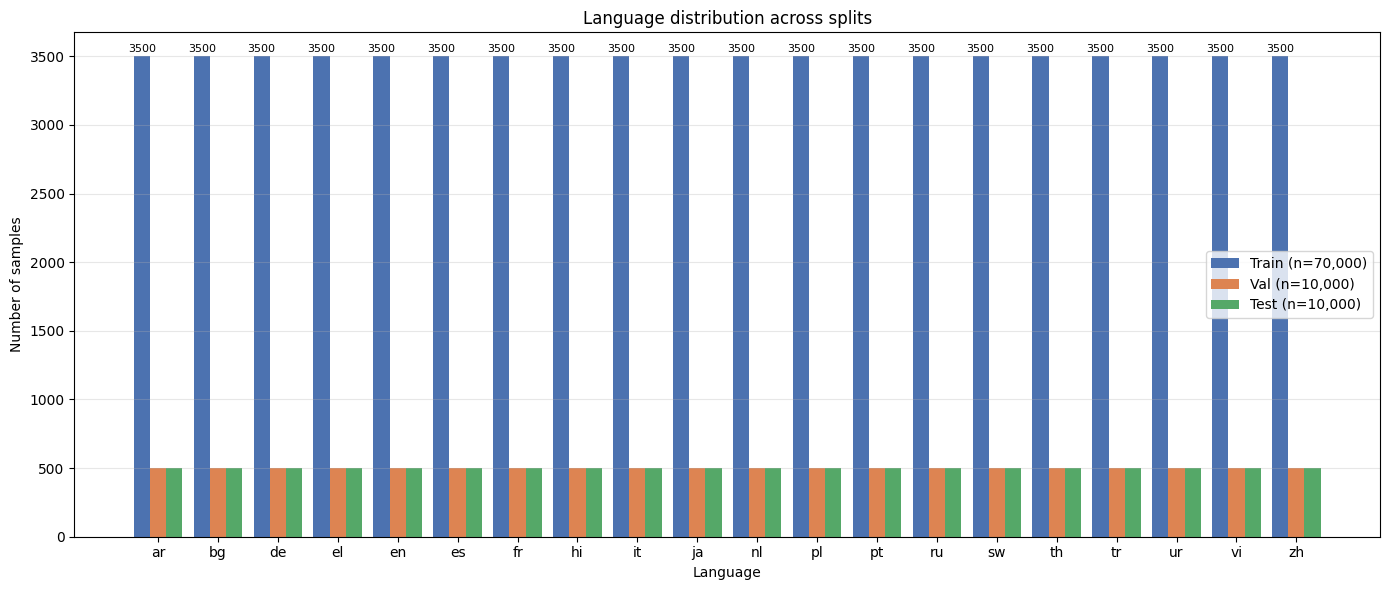

        train  val  test  train_%
labels                           
ar       3500  500   500      5.0
bg       3500  500   500      5.0
de       3500  500   500      5.0
el       3500  500   500      5.0
en       3500  500   500      5.0
es       3500  500   500      5.0
fr       3500  500   500      5.0
hi       3500  500   500      5.0
it       3500  500   500      5.0
ja       3500  500   500      5.0
nl       3500  500   500      5.0
pl       3500  500   500      5.0
pt       3500  500   500      5.0
ru       3500  500   500      5.0
sw       3500  500   500      5.0
th       3500  500   500      5.0
tr       3500  500   500      5.0
ur       3500  500   500      5.0
vi       3500  500   500      5.0
zh       3500  500   500      5.0


In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Count labels in each split
train_counts = train_df["labels"].value_counts().sort_index()
val_counts   = val_df["labels"].value_counts().sort_index()
test_counts  = test_df["labels"].value_counts().sort_index()

languages = train_counts.index.tolist()
x = np.arange(len(languages))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, train_counts.values, width, label=f"Train (n={len(train_df):,})", color="#4C72B0")
ax.bar(x,         val_counts.values,   width, label=f"Val (n={len(val_df):,})",   color="#DD8452")
ax.bar(x + width, test_counts.values,  width, label=f"Test (n={len(test_df):,})", color="#55A868")

ax.set_xlabel("Language")
ax.set_ylabel("Number of samples")
ax.set_title("Language distribution across splits")
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Annotate train bars
for i, v in enumerate(train_counts.values):
    ax.text(i - width, v + max(train_counts.values) * 0.01, str(v),
            ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# Print summary table
import pandas as pd
dist = pd.DataFrame({
    "train": train_counts,
    "val":   val_counts,
    "test":  test_counts,
})
dist["train_%"] = (dist["train"] / dist["train"].sum() * 100).round(2)
print(dist)

# 2. PREPROCESSING
# ─────────────────────────────────────────────

In [ ]:


import re

URL_RE    = re.compile(r"https?://\S+|www\.\S+")
HANDLE_RE = re.compile(r"[@#]\w+")
SPACE_RE  = re.compile(r"\s+")

def preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = URL_RE.sub(" ", text)
    t = HANDLE_RE.sub(" ", t)
    t = SPACE_RE.sub(" ", t).strip()
    return t

# ─────────────────────────────────────────────
# 2b. DROP ENGLISH-CONTAMINATED SWAHILI (operates on raw "text")
# ─────────────────────────────────────────────
ENGLISH_STOP = {
    "the","is","and","of","to","a","in","that","it","for","on","with","as",
    "this","i","you","have","are","be","was","not","but","they","we","he","she",
}

def english_ratio(text: str) -> float:
    words = re.findall(r"[A-Za-z]+", text.lower())
    if not words:
        return 0.0
    return sum(w in ENGLISH_STOP for w in words) / len(words)

before = len(train_df)
mask_bad_sw = (train_df["labels"] == "sw") & (train_df["text"].apply(english_ratio) > 0.25)
train_df = train_df[~mask_bad_sw].reset_index(drop=True)
print(f"Dropped {before - len(train_df)} English-contaminated Swahili samples")

# ─────────────────────────────────────────────
# 2c. AUGMENT WITH SHORT SAMPLES (operates on raw "text")
# ─────────────────────────────────────────────
rng = np.random.default_rng(42)

def make_short_samples(df, n_per_lang=2000, min_words=2, max_words=8):
    rows = []
    for lang, group in df.groupby("labels"):
        texts = group["text"].tolist()
        for _ in range(n_per_lang):
            src = texts[rng.integers(0, len(texts))]
            words = src.split()
            if len(words) < min_words:
                continue
            k = int(rng.integers(min_words, min(max_words, len(words)) + 1))
            start = int(rng.integers(0, len(words) - k + 1))
            rows.append({"text": " ".join(words[start:start + k]), "labels": lang})
    return pd.DataFrame(rows)

short_aug = make_short_samples(train_df, n_per_lang=2000)
train_df = pd.concat([train_df, short_aug], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Train size after augmentation: {len(train_df)}")

# ─────────────────────────────────────────────
# 2d. NOW APPLY PREPROCESS AND EXTRACT X/y
# ─────────────────────────────────────────────
train_df["clean"] = train_df["text"].apply(preprocess)
val_df["clean"]   = val_df["text"].apply(preprocess)
test_df["clean"]  = test_df["text"].apply(preprocess)

X_train, y_train = train_df["clean"], train_df["labels"]
X_val,   y_val   = val_df["clean"],   val_df["labels"]
X_test,  y_test  = test_df["clean"],  test_df["labels"]

Dropped 158 English-contaminated Swahili samples
Train size after augmentation: 107316


In [106]:
# Encoder for XGBoost (requires numeric labels)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_val_num = le.transform(y_val)

In [ ]:
from sklearn.pipeline import FeatureUnion

char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(1, 5),        # made it into (1, 5) to capture more char patterns
    min_df=2,
    max_features=300_000,      # vocab cap
    sublinear_tf=True,
    lowercase=False,
)

word_vec = TfidfVectorizer( # added a word-level vectorizer to capture language-specific words
    analyzer="word",
    ngram_range=(1, 1),       
    min_df=2,
    max_features=150_000,      # vocab cap
    sublinear_tf=True,
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
)

features = FeatureUnion([("char", char_vec), ("word", word_vec)])

# ─────────────────────────────────────────────
# 4. MODELS
# ─────────────────────────────────────────────

In [ ]:

from sklearn.linear_model import SGDClassifier
models = {
    # "Logistic Regression": Pipeline([
    #     ("features", features),
    #     ("clf", LogisticRegression(
    #         max_iter=1000,
    #         C=1.0,
    #         penalty='l2',
    #         solver='lbfgs',
    #         n_jobs=-1,
    #         random_state=42
    #     ))
    # ]),

    # "LinearSVC (calibrated)": Pipeline([
    #     ("features", features),
    #     ("clf", CalibratedClassifierCV(
    #         LinearSVC(
    #             max_iter=2000,
    #             C=0.5,
    #             penalty='l2',
    #             loss='squared_hinge',
    #             dual=False,
    #         ),
    #         method='sigmoid',
    #         cv=5,
    #     )),
    # ]),
    
    "SGD (log loss)": Pipeline([
        ("features", features),
        ("clf", SGDClassifier(
            loss="log_loss",
            alpha=1e-6,
            max_iter=30,
            tol=1e-4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )),
    ]),

    # "Random Forest": Pipeline([
    #     ("features", features),
    #     ("clf", RandomForestClassifier(
    #         n_estimators=300,
    #         max_depth=25,
    #         min_samples_split=5,
    #         min_samples_leaf=2,
    #         max_features='sqrt',
    #         bootstrap=True,
    #         n_jobs=-1,
    #         random_state=42
    #     ))
    # ]),

    # "XGBoost": Pipeline([
    #     ("features", features),
    #     ("clf", XGBClassifier(
    #         n_estimators=300,
    #         max_depth=6,
    #         learning_rate=0.05,
    #         subsample=0.8,
    #         colsample_bytree=0.8,
    #         reg_alpha=0.1,
    #         reg_lambda=1.0,
    #         min_child_weight=3,
    #         gamma=0.1,
    #         n_jobs=-1,
    #         random_state=42,
    #         eval_metric='mlogloss'
    #     ))
    # ]),

    # "Multinomial NB": Pipeline([
    #     ("features", features),
    #     ("clf", MultinomialNB(alpha=0.1))
    # ]),
}

# ─────────────────────────────────────────────
# 5. TRAIN + VALIDATE
# ─────────────────────────────────────────────

In [ ]:

print("=" * 55)
print("Validation results")
print("=" * 55)

val_results = {}
for name, pipeline in models.items():
    # Handle XGBoost numeric labels
    current_y_train = y_train_num if "XGBoost" in name else y_train
    current_y_val = y_val_num if "XGBoost" in name else y_val

    pipeline.fit(X_train, current_y_train)
    val_preds = pipeline.predict(X_val)
    acc = accuracy_score(current_y_val, val_preds)
    val_results[name] = acc
    print(f"{name:<35} Val Accuracy: {acc:.4f}")

best_model_name = max(val_results, key=val_results.get)
print(f"\nBest model on validation set: {best_model_name}")



Validation results
SGD (log loss)                      Val Accuracy: 0.9949

Best model on validation set: SGD (log loss)


# ─────────────────────────────────────────────
# 6. EVALUATE BEST MODEL ON TEST SET
# ─────────────────────────────────────────────

In [ ]:
best_pipeline = models[best_model_name]   # already fitted above

test_preds = best_pipeline.predict(X_test)
test_acc   = accuracy_score(y_test, test_preds)

print("\n" + "=" * 55)
print("TEST SET RESULTS  —  " + best_model_name)
print("=" * 55)
print(f"Accuracy : {test_acc:.4f}\n")
print(classification_report(y_test, test_preds))


TEST SET RESULTS  —  SGD (log loss)
Accuracy : 0.9947

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      0.99      0.99       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      0.99      1.00       500
          pt       1.00      0.99      0.99       500
          ru       0.99      1.00      1.00       500
          sw       0.95      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       0.99  

In [112]:
THRESHOLD = 0.70   # was 0.40 — bump it up

def predict_language(text: str, threshold: float = THRESHOLD) -> dict:
    """
    Returns:
        {
            "language"  : predicted language or "uncertain",
            "confidence": float,
            "reliable"  : bool
        }
    """
    clean = preprocess(text)
    if len(clean) < 3:
        return {"language": "uncertain", "confidence": 0.0, "reliable": False}
    proba = best_pipeline.predict_proba([clean])[0]
    idx = int(np.argmax(proba))
    conf = float(proba[idx])
    lang = best_pipeline.classes_[idx]
    if conf < threshold:
        return {"language": "uncertain", "confidence": conf, "reliable": False}
    return {"language": lang, "confidence": conf, "reliable": True}

it the model was uncertain then we need to use llm prompting (specially is the dataset is a bit far from the real production dataset it doesn't have emojis, the language is formal) so accuracy of the model may drop

# ─────────────────────────────────────────────
# 7. SAVING THE BEST MODEL
# ─────────────────────────────────────────────

In [ ]:

os.makedirs("models-test", exist_ok=True)
joblib.dump(best_pipeline, "models-test/language_detector.pkl")
print("\nModel saved → models-test/language_detector.pkl")


Model saved → models-test/language_detector.pkl


that model will be used in production <br>
as this notebook just for development

In [114]:
file_path = "models-test/language_detector.pkl"
file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 * 1024)
print(f"The size of '{file_path}' is: {file_size_mb:.2f} MB")

The size of 'models-test/language_detector.pkl' is: 73.81 MB


# TESTING

In [139]:
test_cases = [
    ("Hello, how are you doing today?",                          "en"),
    ("شغل عالي من الملك يستحق الإشادة",                          "ar"),
    ("مرحبا، كيف حالك اليوم؟ أتمنى أن تكون بخير يا صديقي",                         "ar"),
    ("I really hate this",                                        "en"),
    ("I think having friends can really help",                       "en"),
    ("Здравей, как си днес приятелю?",                           "bg"),
    ("Ich glaube, Freunde können wirklich helfen",               "de"),
    ("Καλημέρα, πώς είσαι σήμερα φίλε μου;",                     "el"),
    ("Hola, ¿cómo estás hoy mi amigo?",                          "es"),
    ("Je pense que les amis peuvent vraiment aider",             "fr"),
    ("नमस्ते, आज आप कैसे हैं मेरे दोस्त",                              "hi"),
    ("Penso che gli amici possano davvero aiutare",              "it"),
    ("こんにちは、今日は元気ですか友達",                              "ja"),
    ("Hallo, hoe gaat het vandaag met jou?",                     "nl"),
    ("Cześć, jak się masz dzisiaj przyjacielu?",                 "pl"),
    ("Olá, como você está hoje meu amigo?",                      "pt"),
    ("Привет, как дела сегодня мой друг?",                       "ru"),
    ("Habari ya asubuhi rafiki yangu mpendwa",                   "sw"),
    ("สวัสดีครับ วันนี้คุณเป็นอย่างไรบ้าง",                              "th"),
    ("Merhaba, bugün nasılsın dostum?",                          "tr"),
    ("ہیلو، آج آپ کیسے ہیں میرے دوست",                            "ur"),
    ("Xin chào, hôm nay bạn khỏe không bạn ơi",                  "vi"),
    ("你好,今天你过得怎么样我的朋友",                                "zh"),

    ("h, how are you man?",                                                       "en?"),
    ("ok, Thank you very much",                                   "?"),
    ("salut",                                                    "fr"),
    ("danke, wir",                                                    "de"),
    ("gracias",                                                  "es"),
    ("спасибо",                                                  "ru"),
    ("شكرا",                                                     "ar"),
    ("ありがとう",                                                  "ja"),
    ("谢谢",                                                       "zh"),

    ("I think having friends can help me",                       "en"),
    ("شغل عالي من الملك",                                         "ar"),

    ("the cat sat on the mat",                                   "en"),
    ("yes please thank you very much",                           "en"),
    ("no problem at all my friend",                              "en"),

    ("Buenos días",                                              "es"),
    ("Bonjour",                                                  "fr"),
    ("Bom dia",                                                  "pt"),
    ("Buongiorno",                                               "it"),
    ("La casa es muy grande y bonita",                           "es"),
    ("La maison est très grande et belle",                       "fr"),
    ("A casa é muito grande e bonita",                           "pt"),
    ("La casa è molto grande e bella",                           "it"),

    ("Das Wetter ist heute sehr schön",                          "de"),
    ("Het weer is vandaag heel mooi",                            "nl"),

    ("Утро доброе как у вас дела",                               "ru"),
    ("Добро утро как сте днес",                                  "bg"),

    ("Hello مرحبا 你好",                                          "?"),
    ("Привет hello bonjour",                                     "?"),
    ("OMG что это такое lol",                                    "ru"),

    ("Hello my friend 👋😊 how are you?",                         "en"),
    ("Bonjour mon ami 🇫🇷 ça va bien",                            "fr"),
    ("¡Hola amigo! 🎉 ¿cómo estás?",                              "es"),

    ("12345",                                                     "?"),
    ("...!!!???",                                                 "?"),
    ("",                                                          "?"),

    ("Check this out https://example.com it's amazing",          "en"),
    ("Bonjour @user #hashtag visit www.example.fr",              "fr"),

    ("The quick brown fox jumps over the lazy dog near the river bank", "en"),
    ("في يوم من الأيام كان هناك ملك عظيم يحكم بالعدل والحكمة",         "ar"),
    ("Es war einmal ein kleiner Junge der in einem Wald wohnte",       "de"),
]

correct = 0
total_known = 0
for text, expected in test_cases:
    result = predict_language(text)
    pred = result["language"]
    conf = result["confidence"]
    marker = ""
    if expected not in ("?", "en?"):
        total_known += 1
        if pred == expected:
            correct += 1
            marker = "✓"
        else:
            marker = "✗"
    else:
        marker = "·"
    print(f"{marker} {text!r:60} expected={expected:5} → {pred:10} (conf={conf:.3f})")

if total_known:
    print(f"\nAccuracy on known-label cases: {correct}/{total_known} = {correct/total_known:.2%}")

✗ 'Hello, how are you doing today?'                            expected=en    → uncertain  (conf=0.521)
✓ 'شغل عالي من الملك يستحق الإشادة'                            expected=ar    → ar         (conf=0.994)
✓ 'مرحبا، كيف حالك اليوم؟ أتمنى أن تكون بخير يا صديقي'         expected=ar    → ar         (conf=0.987)
✓ 'I really hate this'                                         expected=en    → en         (conf=0.964)
✓ 'I think having friends can really help'                     expected=en    → en         (conf=0.875)
✓ 'Здравей, как си днес приятелю?'                             expected=bg    → bg         (conf=0.907)
✓ 'Ich glaube, Freunde können wirklich helfen'                 expected=de    → de         (conf=0.969)
✓ 'Καλημέρα, πώς είσαι σήμερα φίλε μου;'                       expected=el    → el         (conf=0.989)
✓ 'Hola, ¿cómo estás hoy mi amigo?'                            expected=es    → es         (conf=0.746)
✓ 'Je pense que les amis peuvent vraiment aider'               e